# Aula 02 — Operações Avançadas de Visão Computacional

Neste notebook vamos explorar operações mais avançadas com OpenCV e NumPy:

- Aritmética de imagens (overflow vs saturação)
- Detecção de mudança entre cenas
- Filtro seletivo por cor e efeito Sin City

In [2]:
import sys
sys.path.append('../src')

import importlib
import utils

importlib.reload(utils)

from utils import (
    carregar_imagem,
    exibir_imagem,
    exibir_comparacao,
    somar_imagens_numpy,
    somar_imagens_opencv,
    detectar_mudanca,
    criar_mascara_hsv,
    efeito_sin_city
)

print("Utils recarregado!")

Utils recarregado!


## Exercício 1 — Aritmética e o "Estouro" do Branco

Vamos comparar como o NumPy e o OpenCV lidam com pixels que
ultrapassam o limite de 255 (uint8).

- NumPy: overflow — o valor "dá a volta" e gera artefatos
- OpenCV: saturação — o valor trava em 255, imagem apenas clareia

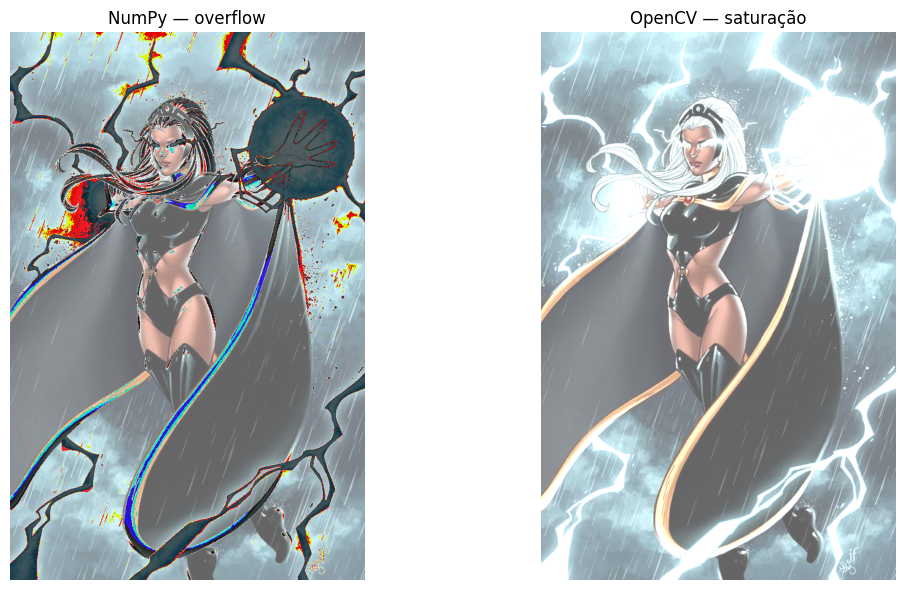

In [3]:
# Carregando a imagem
img = carregar_imagem('../data/input/tempestade.jpg') 

# Somando com NumPy (overflow)
img_numpy = somar_imagens_numpy(img, valor=100)

# Somando com OpenCV (saturação)
img_opencv = somar_imagens_opencv(img, valor=100)

# Comparando os resultados
exibir_comparacao(img_numpy, "NumPy — overflow", img_opencv, "OpenCV — saturação")

In [4]:
# Verificando os valores de um pixel específico
import numpy as np

pixel_original = img[100, 100].astype(int)
pixel_numpy = img_numpy[100, 100].astype(int)
pixel_opencv = img_opencv[100, 100].astype(int)

print(f"Pixel original:      {pixel_original}")
print(f"Pixel NumPy (+100):  {pixel_numpy}")
print(f"Pixel OpenCV (+100): {pixel_opencv}")
print(f"Soma real:           {pixel_original + 100}")

Pixel original:      [60 83 91]
Pixel NumPy (+100):  [160 183 191]
Pixel OpenCV (+100): [160 183 191]
Soma real:           [160 183 191]


## Exercício 2 — O Detetive de Diferenças

Vamos criar um sistema básico de detecção de mudança entre duas cenas.
A ideia é simples: subtrair duas imagens e analisar o resultado.

- Regiões que não mudaram → diferença próxima de 0 (preto)
- Regiões que mudaram → diferença alta (branco)

ALERTA: Mudança detectada! (média: 16.58)


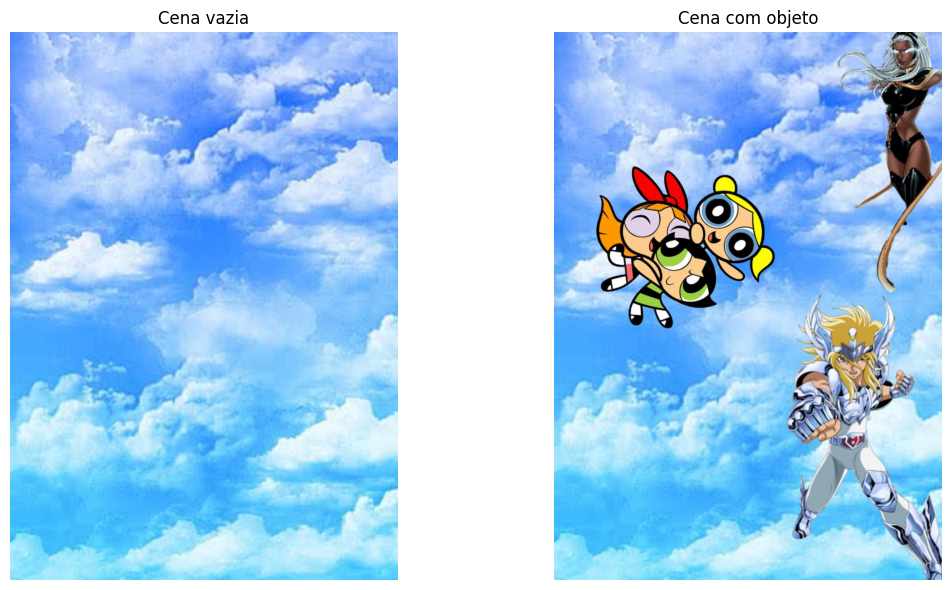

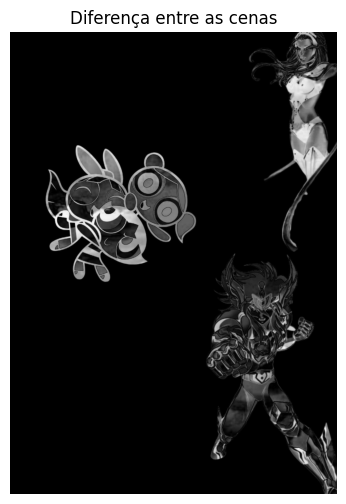

In [5]:
# Carregando as duas cenas
fundo = carregar_imagem('../data/input/fundo.jpg')
objeto = carregar_imagem('../data/input/objeto.jpg')

# Detectando a mudança
diferenca = detectar_mudanca(fundo, objeto)

# Visualizando
exibir_comparacao(fundo, "Cena vazia", objeto, "Cena com objeto")
exibir_imagem(diferenca, "Diferença entre as cenas", cmap="gray")

## Exercício 3 — O Filtro Seletivo e o Efeito Sin City

Vamos isolar um objeto de cor específica e criar o efeito "Sin City":
objeto colorido em cena preto e branco.

1. Convertemos a imagem para HSV
2. Criamos uma máscara da cor escolhida
3. Combinamos o objeto colorido com o fundo P&B

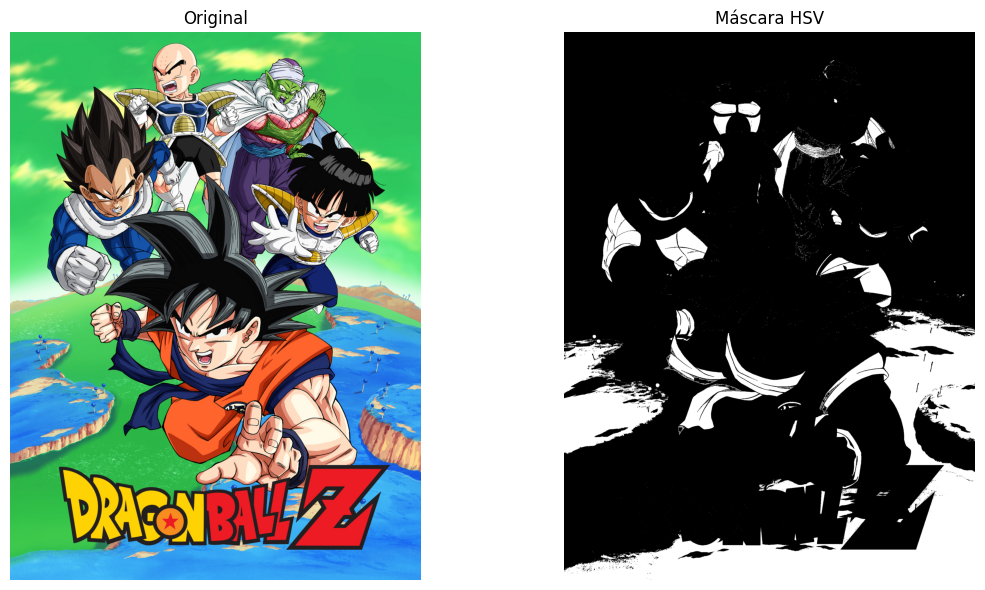

In [10]:
# Carregando uma imagem com objeto de cor vibrante
img = carregar_imagem('../data/input/dragonball.jpg')

# Definindo os limites da cor no espaço HSV
# Exemplo para azul
limite_inf =[100,50,50]
limite_sup =[130,255,255]

# Criando e visualizando a máscara
mascara = criar_mascara_hsv(img, limite_inf, limite_sup)
exibir_comparacao(img, "Original", mascara, "Máscara HSV", cmap2="gray")

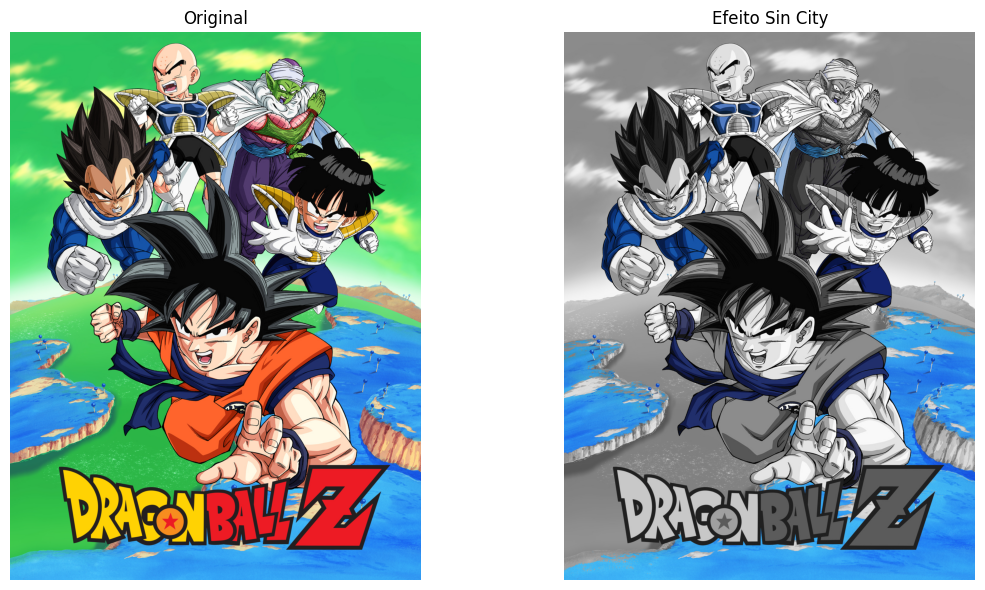

In [11]:
# Aplicando o efeito Sin City
resultado = efeito_sin_city(img, limite_inf, limite_sup)
exibir_comparacao(img, "Original", resultado, "Efeito Sin City")